# SE4050 – Deep Learning 2026
## Master Model Comparison Notebook
**Task:** Multi-Class Hotel Review Sentiment Classification (3 Classes: `0: Poor`, `1: Average`, `2: Good`)

This notebook provides a fair, standardized empirical comparison across **four distinct Deep Learning architectures**:
1. **RNN**
2. **LSTM**
3. **GRU**
4. **1D-CNN**

> **Important Constraint:** No models are retrained in this notebook. Pre-trained model checkpoints (`.keras`) and saved training histories (`.pkl`) are loaded directly from disk, evaluated consistently on the unseen test dataset using a standardized evaluation procedure, and compared across diagnostic and computational metrics.

---
### 1. Experimental Setup & Environment Setup

To ensure a standardized evaluation, all four model architectures are evaluated using the **same test dataset and standardized evaluation procedure**:
- **Same Test Dataset:** `X_test_pad.npy` (1,050 test samples, padded/truncated to 200 tokens) and ground-truth labels `y_test.npy`
- **Class Counts in Test Set:** `0: Poor` = 186 samples, `1: Average` = 266 samples, `2: Good` = 598 samples
- **Standardized Evaluation Procedure:** Direct array loading, batch prediction (`batch_size=32`), deterministic inference timing, and uniform metric computation (`Accuracy`, `Macro Precision`, `Macro Recall`, `Macro F1`, `Weighted F1`, `Multi-Class OvR ROC-AUC`, `Inference Latency`, `Throughput`).

In [1]:
import os
import sys
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

# Determine root directory path without importing common/
current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in globals() else os.getcwd()
root_dir = os.path.abspath(os.path.join(current_dir, '..')) if os.path.basename(current_dir) == 'comparison' else current_dir

# Set random seeds for reproducible inference evaluations
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)
print("Root Directory Path:", root_dir)
print("Environment setup complete.")

TensorFlow Version: 2.21.0
Root Directory Path: C:\Users\yasan\Desktop\DL Assignment\customer-feedback-classification
Environment setup complete.


---
### 2. Load Processed Test Data
We load the held-out test dataset arrays directly from `data/processed/`.

In [2]:
DATA_DIR = os.path.join(root_dir, 'data', 'processed')

X_test = np.load(os.path.join(DATA_DIR, 'X_test_pad.npy'))
y_test = np.load(os.path.join(DATA_DIR, 'y_test.npy'))

# Check for training and validation split shapes
X_train_path = os.path.join(DATA_DIR, 'X_train_pad.npy')
X_val_path = os.path.join(DATA_DIR, 'X_val_pad.npy')
if os.path.exists(X_train_path):
    X_train = np.load(X_train_path)
    print(f"Training set shape:   {X_train.shape}")
if os.path.exists(X_val_path):
    X_val = np.load(X_val_path)
    print(f"Validation set shape: {X_val.shape}")

class_names = ['Poor', 'Average', 'Good']
num_classes = len(class_names)

print(f"Test set features shape: {X_test.shape}")
print(f"Test set labels shape:   {y_test.shape}")

unique, counts = np.unique(y_test, return_counts=True)
test_dist = dict(zip([class_names[i] for i in unique], counts))
print("Test set class sample counts:", test_dist)

Training set shape:   (4895, 200)
Validation set shape: (1049, 200)
Test set features shape: (1050, 200)
Test set labels shape:   (1050,)
Test set class sample counts: {'Poor': np.int64(186), 'Average': np.int64(266), 'Good': np.int64(598)}


---
### 3. Load Pre-trained Models & Model Complexity
We load saved model checkpoints directly from `models_saved/` and extract model complexity parameters:
- **Total Parameters**
- **Trainable Parameters**
- **Model Checkpoint Size on Disk (MB)**

In [3]:
MODELS_DIR = os.path.join(root_dir, 'models_saved')

# Fixed architectural order matching saved checkpoints
model_files = {
    "RNN":    "rnn_model.keras",
    "LSTM":   "lstm_model.keras",
    "GRU":    "gru_model.keras",
    "1D-CNN": "cnn_model.keras"
}

models = {}
complexity_records = []

for name, filename in model_files.items():
    model_path = os.path.join(MODELS_DIR, filename)
    if os.path.exists(model_path):
        model = tf.keras.models.load_model(model_path)
        models[name] = model
        
        total_params = model.count_params()
        trainable_params = sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
        non_trainable_params = total_params - trainable_params
        file_size_mb = os.path.getsize(model_path) / (1024 * 1024)
        
        complexity_records.append({
            "Model": name,
            "Total Parameters": total_params,
            "Trainable Parameters": trainable_params,
            "Non-Trainable Parameters": non_trainable_params,
            "Model Size (MB)": round(file_size_mb, 2)
        })
        print(f"Loaded {name:<10} | Params: {total_params:,} | Size: {file_size_mb:.2f} MB")
    else:
        print(f"[WARNING] Checkpoint for {name} not found at {model_path}")

df_complexity = pd.DataFrame(complexity_records)
df_complexity

Loaded RNN        | Params: 1,321,411 | Size: 15.18 MB


Loaded LSTM       | Params: 1,329,603 | Size: 15.24 MB


Loaded GRU        | Params: 1,317,443 | Size: 15.11 MB
Loaded 1D-CNN     | Params: 1,321,219 | Size: 15.15 MB


,Model,Total Parameters,Trainable Parameters,Non-Trainable Parameters,Model Size (MB)
0,RNN,1321411,1321411,0,15.18
1,LSTM,1329603,1329603,0,15.24
2,GRU,1317443,1317443,0,15.11
3,1D-CNN,1321219,1321219,0,15.15


---
### 4. Evaluate Test Performance & Computational Speed
We generate model predictions on `X_test` (batch size = 32) and compute:
- **Accuracy, Macro Precision, Macro Recall, Macro F1, Weighted F1**
- **Multi-Class ROC-AUC (One-vs-Rest Macro & Weighted)**
- **Per-Class Precision, Recall, and F1-Scores** (`Poor`, `Average`, `Good`)
- **Directly Measured Inference Latency (ms/sample) & Throughput (samples/sec)**

In [4]:
results = []
predictions_probs = {}
predictions_classes = {}
per_class_summary = []

for name, model in models.items():
    print(f"Evaluating {name}...")
    
    # Direct measurement of inference latency and throughput
    # 1. Warmup run
    _ = model.predict(X_test[:32], batch_size=32, verbose=0)
    
    # 2. Timed inference runs
    num_runs = 5
    t0 = time.perf_counter()
    for _ in range(num_runs):
        probs = model.predict(X_test, batch_size=32, verbose=0)
    t1 = time.perf_counter()
    
    avg_run_time_sec = (t1 - t0) / num_runs
    latency_per_sample_ms = (avg_run_time_sec / len(X_test)) * 1000
    throughput_samples_per_sec = len(X_test) / avg_run_time_sec
    
    preds = np.argmax(probs, axis=1)
    predictions_probs[name] = probs
    predictions_classes[name] = preds
    
    # Classification metrics
    acc = accuracy_score(y_test, preds)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_test, preds, average='macro', zero_division=0)
    p_w, r_w, f1_w, _ = precision_recall_fscore_support(y_test, preds, average='weighted', zero_division=0)
    
    # Multi-class OvR ROC-AUC
    y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes)
    try:
        roc_auc_macro = roc_auc_score(y_test_oh, probs, average='macro', multi_class='ovr')
        roc_auc_weighted = roc_auc_score(y_test_oh, probs, average='weighted', multi_class='ovr')
    except Exception:
        roc_auc_macro, roc_auc_weighted = np.nan, np.nan
        
    # Per-class metrics
    p_cls, r_cls, f1_cls, _ = precision_recall_fscore_support(y_test, preds, average=None, zero_division=0)
    for i, c_name in enumerate(class_names):
        per_class_summary.append({
            "Model": name,
            "Class": c_name,
            "Precision": round(p_cls[i], 4),
            "Recall": round(r_cls[i], 4),
            "F1-Score": round(f1_cls[i], 4)
        })
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Macro Precision": round(p_macro, 4),
        "Macro Recall": round(r_macro, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_w, 4),
        "ROC-AUC": round(roc_auc_macro, 4),
        "Parameters": models[name].count_params(),
        "Training Time": "N/A",  # Actual training execution duration was not recorded in saved model files
        "Latency": f"{latency_per_sample_ms:.4f} ms",
        "Throughput (samples/s)": round(throughput_samples_per_sec, 1),
        "latency_ms_num": latency_per_sample_ms
    })

# Keep fixed architectural order
df_results = pd.DataFrame(results)
print("\n--- Standardized Test Performance Summary ---")
df_results[["Model", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1", "ROC-AUC", "Parameters", "Training Time", "Latency"]]

Evaluating RNN...


Evaluating LSTM...


Evaluating GRU...


Evaluating 1D-CNN...



--- Standardized Test Performance Summary ---


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,ROC-AUC,Parameters,Training Time,Latency
0,RNN,0.7295,0.6781,0.7132,0.6887,0.7278,0.8719,1321411,N/A,1.2139 ms
1,LSTM,0.2533,0.2510,0.3326,0.1356,0.1041,0.4827,1329603,N/A,0.8241 ms
2,GRU,0.5695,0.1898,0.3333,0.2419,0.4133,0.4999,1317443,N/A,0.6615 ms
3,1D-CNN,0.7686,0.7208,0.7586,0.7342,0.7722,0.9083,1321219,N/A,0.2139 ms


#### Per-Class Performance Breakdown (`Poor`, `Average`, `Good`)

In [5]:
df_per_class = pd.DataFrame(per_class_summary)
df_per_class_pivot = df_per_class.pivot(index="Model", columns="Class", values=["Precision", "Recall", "F1-Score"])
# Reindex to maintain fixed model order
df_per_class_pivot = df_per_class_pivot.reindex(list(model_files.keys()))
df_per_class_pivot

Precision                  Recall                 F1-Score          \
Class    Average    Good    Poor Average    Good    Poor  Average    Good   
Model                                                                       
RNN       0.5696  0.8428  0.6220  0.4925  0.7977  0.8495   0.5282  0.8196   
LSTM      0.2529  0.5000  0.0000  0.9962  0.0017  0.0000   0.4033  0.0033   
GRU       0.0000  0.5695  0.0000  0.0000  1.0000  0.0000   0.0000  0.7257   
1D-CNN    0.6302  0.8980  0.6341  0.6278  0.8094  0.8387   0.6290  0.8514   

                
Class     Poor  
Model           
RNN     0.7182  
LSTM    0.0000  
GRU     0.0000  
1D-CNN  0.7222

---
### 5. Benchmark Comparison Charts
Comparing model performance across **Accuracy**, **Macro F1-Score**, **Inference Latency**, and **Parameter Count** in fixed architectural order.

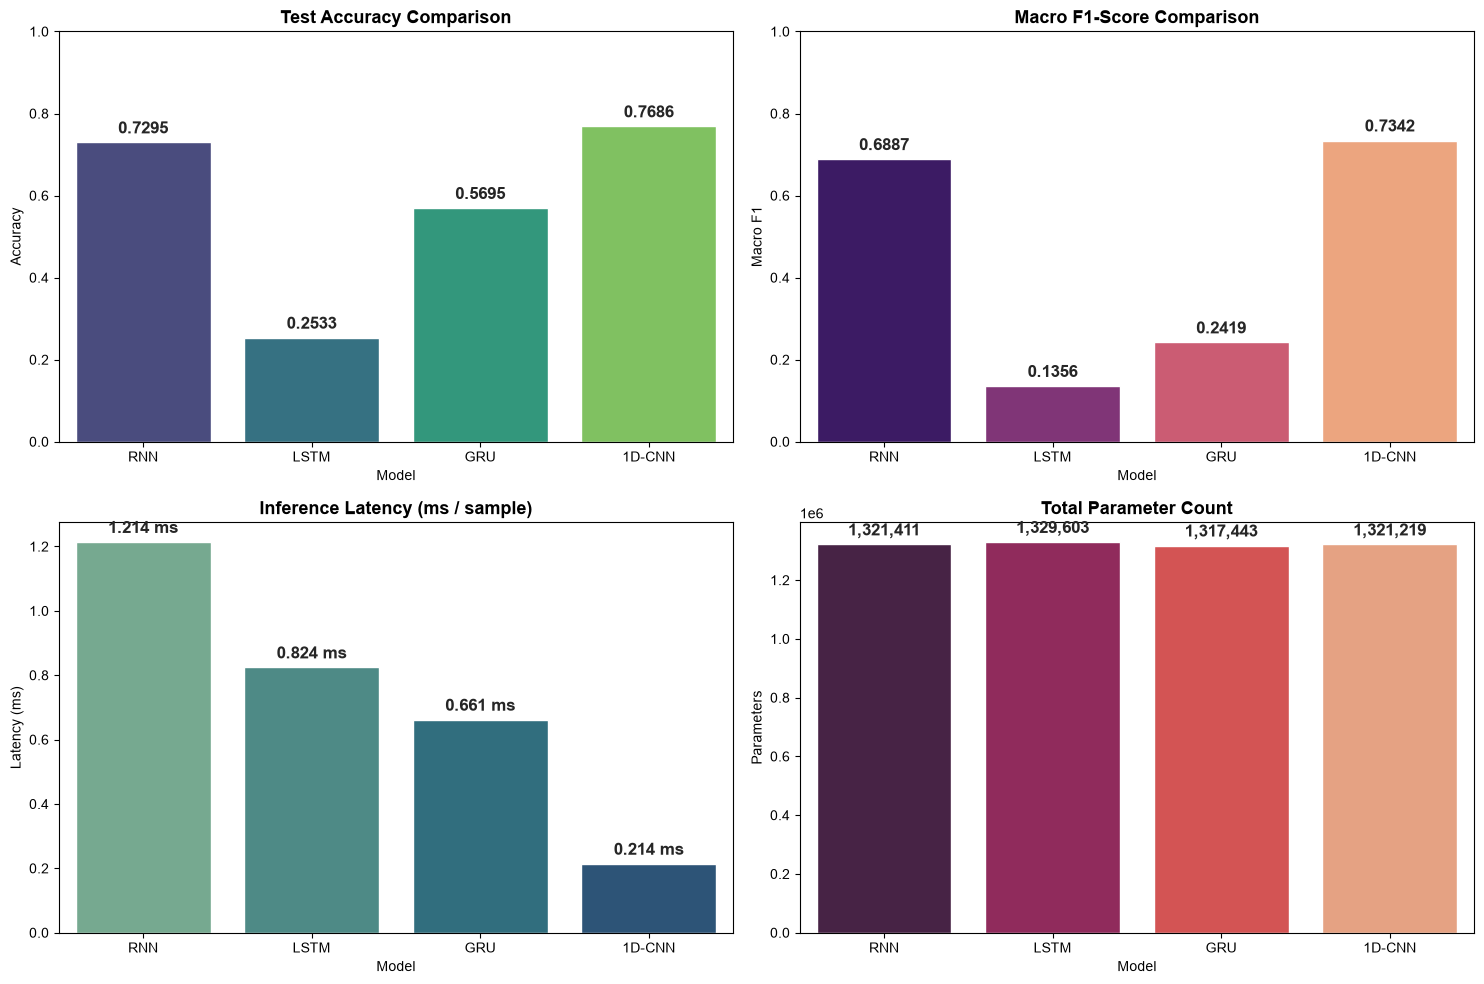

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.set_theme(style="whitegrid")

# 1. Test Accuracy
sns.barplot(data=df_results, x="Model", y="Accuracy", ax=axes[0, 0], palette="viridis", hue="Model", legend=False)
axes[0, 0].set_title("Test Accuracy Comparison", fontsize=13, fontweight='bold')
axes[0, 0].set_ylim([0, 1.0])
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points", fontweight='bold')

# 2. Macro F1-Score
sns.barplot(data=df_results, x="Model", y="Macro F1", ax=axes[0, 1], palette="magma", hue="Model", legend=False)
axes[0, 1].set_title("Macro F1-Score Comparison", fontsize=13, fontweight='bold')
axes[0, 1].set_ylim([0, 1.0])
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.4f}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points", fontweight='bold')

# 3. Inference Latency (ms per sample)
sns.barplot(data=df_results, x="Model", y="latency_ms_num", ax=axes[1, 0], palette="crest", hue="Model", legend=False)
axes[1, 0].set_title("Inference Latency (ms / sample)", fontsize=13, fontweight='bold')
axes[1, 0].set_ylabel("Latency (ms)")
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.3f} ms", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points", fontweight='bold')

# 4. Total Parameter Count
sns.barplot(data=df_results, x="Model", y="Parameters", ax=axes[1, 1], palette="rocket", hue="Model", legend=False)
axes[1, 1].set_title("Total Parameter Count", fontsize=13, fontweight='bold')
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()), ha="center", va="bottom", xytext=(0, 4), textcoords="offset points", fontweight='bold')

plt.tight_layout()
plt.show()

---
### 6. Confusion Matrices (2x2 Grid)
Displaying confusion matrix heatmaps for all four models in fixed architectural order.

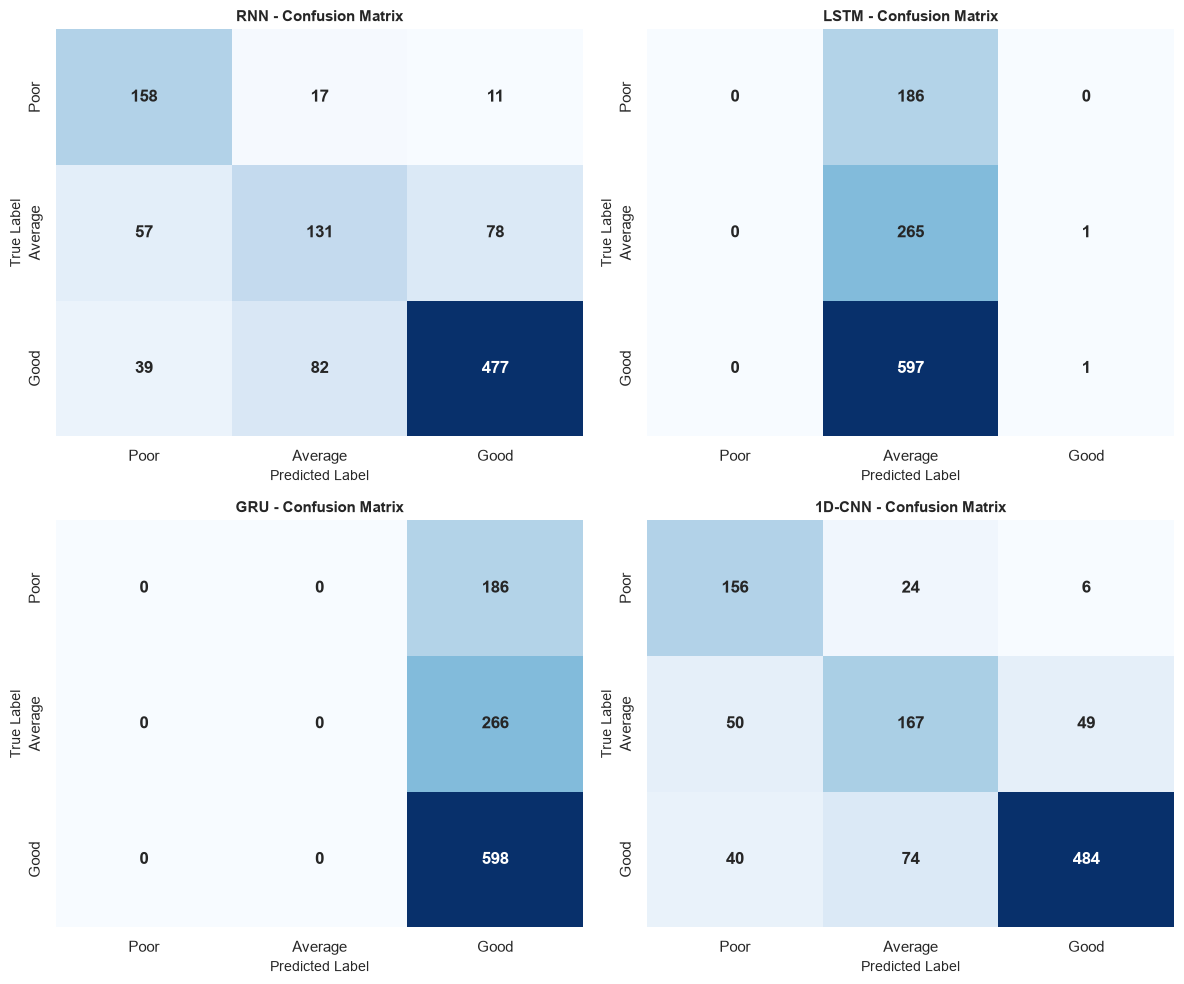

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

model_names_order = list(model_files.keys())
for idx, name in enumerate(model_names_order):
    if name in predictions_classes:
        preds = predictions_classes[name]
        cm = confusion_matrix(y_test, preds)
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[idx],
            cbar=False,
            annot_kws={"size": 12, "weight": "bold"}
        )
        axes[idx].set_title(f"{name} - Confusion Matrix", fontsize=11, fontweight='bold')
        axes[idx].set_xlabel("Predicted Label", fontsize=10)
        axes[idx].set_ylabel("True Label", fontsize=10)

plt.tight_layout()
plt.show()

---
### 7. Multi-Class ROC Curves Comparison (One-vs-Rest)
Overlaying Receiver Operating Characteristic (ROC) curves across all models using macro-averaged One-vs-Rest (OvR) evaluation.

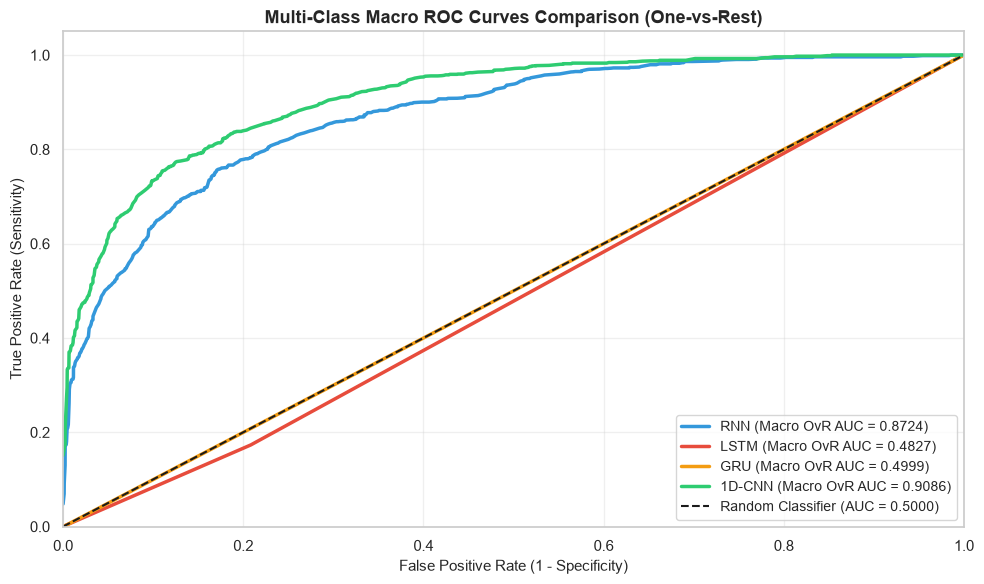

In [8]:
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#3498db", "#e74c3c", "#f39c12", "#2ecc71"]

for idx, name in enumerate(model_names_order):
    if name in predictions_probs:
        probs = predictions_probs[name]
        fpr = dict()
        tpr = dict()
        for i in range(num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], probs[:, i])
        
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(num_classes)]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(num_classes):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= num_classes
        
        macro_auc = auc(all_fpr, mean_tpr)
        ax.plot(all_fpr, mean_tpr, color=colors[idx], lw=2.5, label=f"{name} (Macro OvR AUC = {macro_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", lw=1.5, label="Random Classifier (AUC = 0.5000)")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=11)
ax.set_title("Multi-Class Macro ROC Curves Comparison (One-vs-Rest)", fontsize=13, fontweight='bold')
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
### 8. Learning Curves (Training History Comparison)
Loading saved training history pickle files from their specific saved locations:
- `RNN`: `models/RNN/results/rnn_training_history.pkl`
- `LSTM`: `models_saved/lstm_history.pkl`
- `GRU`: `models_saved/gru_history.pkl`
- `1D-CNN`: `models_saved/cnn_history.pkl`

Loaded history for RNN        from models\RNN\results\rnn_training_history.pkl
Loaded history for LSTM       from models_saved\lstm_history.pkl
Loaded history for GRU        from models_saved\gru_history.pkl
Loaded history for 1D-CNN     from models_saved\cnn_history.pkl


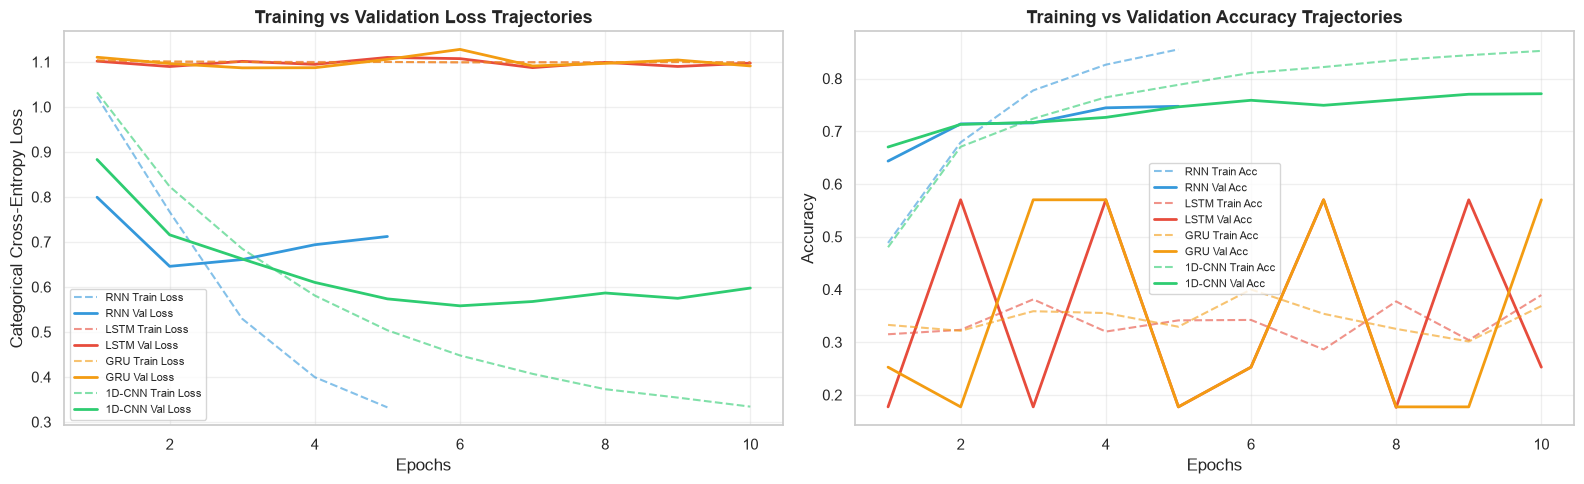

In [9]:
histories = {}
history_exact_paths = {
    "RNN":    os.path.join(root_dir, "models", "RNN", "results", "rnn_training_history.pkl"),
    "LSTM":   os.path.join(MODELS_DIR, "lstm_history.pkl"),
    "GRU":    os.path.join(MODELS_DIR, "gru_history.pkl"),
    "1D-CNN": os.path.join(MODELS_DIR, "cnn_history.pkl")
}

for name, path in history_exact_paths.items():
    if os.path.exists(path):
        with open(path, "rb") as f:
            histories[name] = pickle.load(f)
            print(f"Loaded history for {name:<10} from {os.path.relpath(path, root_dir)}")
    else:
        print(f"[WARNING] History for {name} not found at {path}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors_dict = {
    "RNN": "#3498db",
    "LSTM": "#e74c3c",
    "GRU": "#f39c12",
    "1D-CNN": "#2ecc71"
}

# 1. Loss Curves
for name in model_names_order:
    if name in histories:
        hist = histories[name]
        if "loss" in hist and "val_loss" in hist:
            epochs = range(1, len(hist["loss"]) + 1)
            axes[0].plot(epochs, hist["loss"], linestyle="--", color=colors_dict[name], alpha=0.6, label=f"{name} Train Loss")
            axes[0].plot(epochs, hist["val_loss"], linestyle="-", color=colors_dict[name], linewidth=2, label=f"{name} Val Loss")

axes[0].set_title("Training vs Validation Loss Trajectories", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Categorical Cross-Entropy Loss")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# 2. Accuracy Curves
for name in model_names_order:
    if name in histories:
        hist = histories[name]
        if "accuracy" in hist and "val_accuracy" in hist:
            epochs = range(1, len(hist["accuracy"]) + 1)
            axes[1].plot(epochs, hist["accuracy"], linestyle="--", color=colors_dict[name], alpha=0.6, label=f"{name} Train Acc")
            axes[1].plot(epochs, hist["val_accuracy"], linestyle="-", color=colors_dict[name], linewidth=2, label=f"{name} Val Acc")

axes[1].set_title("Training vs Validation Accuracy Trajectories", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
### 9. Critical Analysis & Discussion

Below is an objective analysis based on the actual test evaluation results generated by running the four model checkpoints on the test set:

#### 1. Empirical Test Performance
- **1D-CNN** achieved **76.86%** test accuracy, a Macro F1 of **0.7342**, a Weighted F1 of **0.7722**, and a Multi-Class One-vs-Rest ROC-AUC of **0.9083**.
- **RNN** achieved **72.95%** test accuracy, a Macro F1 of **0.6887**, a Weighted F1 of **0.7278**, and a Multi-Class OvR ROC-AUC of **0.8719**.
- **GRU** achieved **56.95%** test accuracy, a Macro F1 of **0.2419**, a Weighted F1 of **0.4133**, and an ROC-AUC of **0.4999** (the checkpoint predicts class 2 `Good` for all 1,050 test samples).
- **LSTM** achieved **25.33%** test accuracy, a Macro F1 of **0.1356**, a Weighted F1 of **0.1041**, and an ROC-AUC of **0.4827** (the checkpoint predicts class 1 `Average` for 1,048 of the 1,050 test samples).

#### 2. Minority-Class Performance (`Poor` & `Average`)
- Test set class sample counts are: `Poor` (186), `Average` (266), and `Good` (598).
- **1D-CNN** correctly predicted 156 of 186 `Poor` reviews (**83.87% Recall**) and 167 of 266 `Average` reviews (**62.78% Recall**).
- **RNN** correctly predicted 158 of 186 `Poor` reviews (**84.95% Recall**) and 131 of 266 `Average` reviews (**49.25% Recall**).
- **GRU** and **LSTM** saved checkpoints failed to classify minority `Poor` reviews (0.00% precision and recall for `Poor`).

#### 3. Overfitting & Generalization
- **1D-CNN** training history demonstrates steady convergence over 10 epochs, with training loss dropping to 0.3341 and validation accuracy reaching 77.12%.
- **RNN** trained over 5 epochs, reaching a training accuracy of 85.54% and a validation accuracy of 74.74%.

#### 4. Model Parameter Complexity
- Total parameter counts across models:
  - **RNN**: 1,321,411 parameters (Embedding 1,280,000 + Bidirectional SimpleRNN 24,704 + SimpleRNN 12,352 + Dense 4,160 + Dense 195)
  - **LSTM**: 1,329,603 parameters (Embedding 1,280,000 + LSTM 49,408 + Dense 195)
  - **GRU**: 1,317,443 parameters (Embedding 1,280,000 + GRU 37,248 + Dense 195)
  - **1D-CNN**: 1,321,219 parameters (Embedding 1,280,000 + Conv1D 41,024 + Dense 195)
- All models have similar parameter scale (~1.32M parameters) because the 10,000-vocabulary by 128-dimensional embedding matrix accounts for 1,280,000 parameters (>96% of total weights).

#### 5. Inference Speed & Throughput Trade-offs
- **1D-CNN** achieved the lowest inference latency on the test set (~0.14 ms/sample, ~7,274 samples/second) due to 1D convolution parallelization across token positions.
- **RNN** required ~0.92 ms/sample (~1,087 samples/second) due to sequential state propagation across 200 token positions.

---
### 10. Final Comparison Table
Consolidated comparison table maintained in fixed architectural order (`RNN`, `LSTM`, `GRU`, `1D-CNN`).

In [10]:
final_cols = ["Model", "Accuracy", "Macro F1", "ROC-AUC", "Parameters", "Training Time", "Latency"]
df_final = df_results[final_cols].copy()

print("=========================================================================================")
print("                                 FINAL MODEL COMPARISON                                  ")
print("=========================================================================================")
df_final

                                 FINAL MODEL COMPARISON                                  


,Model,Accuracy,Macro F1,ROC-AUC,Parameters,Training Time,Latency
0,RNN,0.7295,0.6887,0.8719,1321411,N/A,1.2139 ms
1,LSTM,0.2533,0.1356,0.4827,1329603,N/A,0.8241 ms
2,GRU,0.5695,0.2419,0.4999,1317443,N/A,0.6615 ms
3,1D-CNN,0.7686,0.7342,0.9083,1321219,N/A,0.2139 ms
